# Last.fm bench

Compare embedding recommendations against Last.fm results.

In [16]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

## Data Prep

In [17]:
DATA_DIR = Path("../datasets")
BENCH_PATH = DATA_DIR / "lastfm_recommendations_all_top_listener.csv"
RECS_PATH = DATA_DIR / "final_recs.parquet"
CATALOG_PATH = DATA_DIR / "albums.csv"

# Number of top recommendations to keep for each query album
TOP_N = 5

In [18]:
# utility functions
def _top_n_subset(df, top_n):
    """Keep ranks 1..top_n and drop query albums with fewer than top_n recs."""
    sub = df[df["rank"] <= top_n].copy()
    keys = ["query_artist", "query_album"]
    n_recs = sub.groupby(keys, observed=True)["rank"].transform("count")
    return sub[n_recs >= top_n].reset_index(drop=True)


def keep_top_n(df, top_n=TOP_N, verbose=True):
    keys = ["query_artist", "query_album"]
    n_queries_before = df[df["rank"] <= top_n].groupby(keys, observed=True).ngroups
    out = _top_n_subset(df, top_n)
    if verbose:
        n_queries_after = out.groupby(keys, observed=True).ngroups
        print(f"Kept {n_queries_after:,} / {n_queries_before:,} query albums with >={top_n} recs")
    return out


def _norm_str(s) -> str:
    """Same normalization as ingestion/albums.ipynb (quotes, accents, whitespace)."""
    s = str(s).strip().lower()
    for ch in ("\u2019", "\u2018", "\u201b", "\u2032", "`", "\u00b4"):
        s = s.replace(ch, "'")
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", s)


def _norm(s: pd.Series) -> pd.Series:
    return s.fillna("").map(_norm_str)


def query_key(df):
    """Normalized artist::album key for query albums."""
    return _norm(df["query_artist"]) + "::" + _norm(df["query_album"])


def rec_key(df):
    """Normalized artist::album key for recommended albums."""
    return _norm(df["rec_artist"]) + "::" + _norm(df["rec_album"])


def metric_row(metric, recommender=None, **values):
    """One metrics row for pd.DataFrame append/concat."""
    row = {"metric": metric, **values}
    if recommender is not None:
        row["recommender"] = recommender
    return row


SLOT_KEYS = ["_query_key", "rank"]


def _slot_set(df, mask):
    sub = df.loc[mask(df)]
    if sub.empty:
        return set()
    return set(zip(query_key(sub), sub["rank"]))


def has_listener_data(df):
    return df["rec_listeners"].notna() & df["query_listeners"].notna()


def has_rec_tags(df):
    tags = df["rec_tags"].astype("string")
    return tags.notna() & tags.str.strip().ne("")


def comparable_slots(recs_df, baseline_df, mask_fn):
    """Rec slots (normalized query, rank) where both recommenders pass mask_fn."""
    return _slot_set(recs_df, mask_fn) & _slot_set(baseline_df, mask_fn)


def filter_comparable_slots(df, slots):
    if not slots:
        return df.iloc[0:0].copy()
    idx = pd.MultiIndex.from_arrays([query_key(df), df["rank"]])
    return df.loc[idx.isin(slots)].copy()


def parse_tag_string(val):
    """Semicolon-separated Last.fm / MB tag strings -> normalized tag list."""
    if pd.isna(val):
        return []
    return [tag.strip().lower() for tag in str(val).split(";") if tag.strip()]


def explode_rec_tags(df):
    """One row per (rec slot, tag); drops rows with no tags."""
    pieces = []
    base_cols = [c for c in df.columns if c != "rec_tag"]
    for row in df[base_cols].itertuples(index=False):
        row_dict = dict(zip(base_cols, row))
        for tag in parse_tag_string(row_dict.get("rec_tags")):
            pieces.append({**row_dict, "rec_tag": tag})
    if not pieces:
        return pd.DataFrame(columns=[*base_cols, "rec_tag"])
    return pd.DataFrame(pieces)


In [19]:
# Load the album catalog from the CSV file containing metadata for all albums reviewed in the dataset
catalog = pd.read_csv(CATALOG_PATH)
catalog["key"] = _norm(catalog["artist"]) + "::" + _norm(catalog["album"])
catalog_reviews = catalog.set_index("key")["review_count"]
catalog_ids = catalog.set_index("key")["album_id"]
catalog_listeners = (
    catalog.set_index("key")["lastfm_listeners"]
    if "lastfm_listeners" in catalog.columns
    else pd.Series(dtype="Float64")
)
print(f"Catalog: {len(catalog):,} albums")

Catalog: 30,516 albums


In [ ]:
# Load embedding recs (with Last.fm listeners/tags joined in ingestion/lastfm_album_metadata.ipynb).
recs = pd.read_parquet(RECS_PATH)
recs = recs.drop(columns=["rec_length_flag"], errors="ignore")
recs = recs.rename(columns={
    "query_lastfm_listeners": "query_listeners",
    "rec_lastfm_listeners": "rec_listeners",
    "query_lastfm_tags": "query_tags",
    "rec_lastfm_tags": "rec_tags",
})

In [ ]:
# Load and sanitize recommendations from Last.fm benchmark recommender.
df = pd.read_csv(BENCH_PATH)
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["rank"] = pd.to_numeric(df["rank"], errors="coerce")
for col in ("seed_listeners", "rec_listeners"):
    df[col] = pd.to_numeric(df[col], errors="coerce")

# keep successful recommendations only
df = df[df["status"] == "ok"].reset_index(drop=True)

n_albums = df["album_id"].nunique()
print(f"File: {BENCH_PATH.name}")
print(f"Strategy: {df['strategy'].iloc[0]}  |  Albums: {n_albums:,}  |  Rec rows: {len(df):,}")

baseline = df.rename(columns={
    "artist": "query_artist",
    "album":  "query_album",
    "seed_listeners": "query_listeners",
}).reindex(columns=[
    "album_id", "query_artist", "query_album", "rec_artist", "rec_album",
    "score", "rank", "query_listeners", "rec_listeners", "rec_tags",
]).copy()
for col in ("rec_tags",):
    baseline[col] = baseline[col].astype("string")


baseline_n = keep_top_n(baseline)
baseline_1 = keep_top_n(baseline, 1)

File: lastfm_recommendations_all_top_listener.csv
Strategy: top_listener  |  Albums: 7,278  |  Rec rows: 30,103
Kept 2,941 / 7,278 query albums with >=5 recs
Kept 7,278 / 7,278 query albums with >=1 recs


### Match to baseline queries

Keep only embedding recs whose query album appears in the Last.fm baseline (normalized artist::album match). If the embedding corpus has duplicate spellings of the same album (e.g. curly vs straight apostrophes), keep one variant per normalized key so query counts align with the baseline.

In [ ]:
baseline_query_keys = set(query_key(baseline))

def filter_to_baseline(df):
    out = df.loc[query_key(df).isin(baseline_query_keys)].copy()
    out["_query_key"] = query_key(out)

    canonical = (
        out.groupby("_query_key", observed=True)[["query_artist", "query_album"]]
        .first()
        .rename(columns={"query_artist": "_canon_artist", "query_album": "_canon_album"})
    )
    out = out.join(canonical, on="_query_key")
    out = out[
        (out["query_artist"] == out["_canon_artist"])
        & (out["query_album"] == out["_canon_album"])
    ].drop(columns=["_query_key", "_canon_artist", "_canon_album"]).reset_index(drop=True)

    n_queries = out.groupby(["query_artist", "query_album"], observed=True).ngroups
    print(f"{len(out):,} rows, {n_queries:,} queries")
    return out

print("Embedding recs (matched to baseline):")
recs_matched = filter_to_baseline(recs)
recs_1 = keep_top_n(recs_matched, 1)
recs_n = keep_top_n(recs_matched)

Embedding recs (matched to baseline):
72,780 rows, 7,278 queries
Kept 7,278 / 7,278 query albums with >=1 recs
Kept 7,278 / 7,278 query albums with >=5 recs


### Listener / tag overlap

Listener and tag metrics use only **comparable slots**: `(normalized query album, rank)` rows where **both** recommenders have the required Last.fm field (`rec_listeners` + `query_listeners` for listener metrics; non-empty `rec_tags` for tag metrics). Slots are matched on normalized artist::album keys so spelling differences between emb and baseline don't zero out the overlap.

In [ ]:
listener_slots_n = comparable_slots(recs_n, baseline_n, has_listener_data)
tag_slots_n = comparable_slots(recs_n, baseline_n, has_rec_tags)

recs_n_listeners = filter_comparable_slots(recs_n, listener_slots_n)
baseline_n_listeners = filter_comparable_slots(baseline_n, listener_slots_n)
recs_n_tags = filter_comparable_slots(recs_n, tag_slots_n)
baseline_n_tags = filter_comparable_slots(baseline_n, tag_slots_n)

print(f"Comparable listener slots (top-{TOP_N}): {len(listener_slots_n):,} / {len(recs_n):,} emb rows ({len(listener_slots_n) / len(recs_n):.1%})")
print(f"Comparable tag slots (top-{TOP_N}):      {len(tag_slots_n):,} / {len(recs_n):,} emb rows ({len(tag_slots_n) / len(recs_n):.1%})")

Comparable listener slots (top-5): 4,852 / 36,390 emb rows (13.3%)
Comparable tag slots (top-5):      3,036 / 36,390 emb rows (8.3%)


# Comparisons

Each recommender has two views: `*_1` (rank-1 only — top-pick metrics) and `*_n` (full top-N lists — list-level metrics). Embedding recs are restricted to query albums present in the Last.fm baseline.

## Repetition

Do different query albums get steered toward the same recommended **albums**, **artists**, and **tags**? We sweep list depth `n = 1 … TOP_N` and measure how concentrated recommendations are.

The embedding model draws from a **much smaller catalog** than Last.fm, so some extra repetition is expected.

**How to read:** focus on **n = 1** (top pick) and **n = TOP_N** (full list). **Unique share** = distinct targets ÷ rec slots (for tags: distinct tags ÷ tag mentions). **Hubs** = distinct targets recommended to more than one query. Tag metrics use comparable slots where both recommenders have `rec_tags` (matched on normalized query + rank).

### Albums

At each `n`:

- **Unique share** — fraction of rec slots that point to distinct album titles (higher = more diverse).
- **Repeated hubs** — count of distinct albums recommended as a top pick for *more than one* query album. Each hub is a target the recommender keeps returning across unrelated queries; a high count means many queries get steered toward the same albums.

In [ ]:
def repeated_stats(df, rec_col):
    counts = df[rec_col].str.strip().str.lower().value_counts()
    n_total = len(df)
    n_unique = counts.size
    n_repeated = int((counts > 1).sum())
    return {
        "n_total": n_total,
        "n_queries": df.groupby(["query_artist", "query_album"], observed=True).ngroups,
        "n_unique": n_unique,
        "n_repeated": n_repeated,
        "unique_share": n_unique / n_total if n_total else float("nan"),
        "repeated_share": n_repeated / n_unique if n_unique else float("nan"),
    }


def _top_n_subset(df, top_n):
    """Keep ranks 1..top_n; quiet helper (also defined in Data Prep)."""
    sub = df[df["rank"] <= top_n].copy()
    keys = ["query_artist", "query_album"]
    n_recs = sub.groupby(keys, observed=True)["rank"].transform("count")
    return sub[n_recs >= top_n].reset_index(drop=True)


def repeated_sweep(recs_df, baseline_df, rec_col, metric, top_n=TOP_N):
    rows = []
    for n in range(1, top_n + 1):
        for label, source in [("embedding recs", recs_df), ("last.fm baseline", baseline_df)]:
            sub = _top_n_subset(source, n)
            stats = repeated_stats(sub, rec_col)
            rows.append({"metric": metric, "n": n, "recommender": label, **stats})
    return pd.DataFrame(rows)


repeated_sweep_albums = repeated_sweep(recs_matched, baseline, "rec_album", "repeated_albums")
repeated_sweep_albums

,metric,n,recommender,n_total,n_queries,n_unique,n_repeated,unique_share,repeated_share
0,repeated_albums,1,embedding recs,7278,7278,4532,1316,0.622699,0.290380
1,repeated_albums,1,last.fm baseline,7278,7278,6084,819,0.835944,0.134615
2,repeated_albums,2,embedding recs,14556,7278,7473,2806,0.513397,0.375485
3,repeated_albums,2,last.fm baseline,14446,7223,11073,2026,0.766510,0.182968
4,repeated_albums,3,embedding recs,21834,7278,9704,4221,0.444444,0.434975
5,repeated_albums,3,last.fm baseline,20796,6932,14936,3160,0.718215,0.211569
6,repeated_albums,4,embedding recs,29112,7278,11505,5447,0.395198,0.473446
7,repeated_albums,4,last.fm baseline,22916,5729,15837,3603,0.691089,0.227505
8,repeated_albums,5,embedding recs,36390,7278,13016,6622,0.357681,0.508758
9,repeated_albums,5,last.fm baseline,14705,2941,10848,2135,0.737708,0.196810


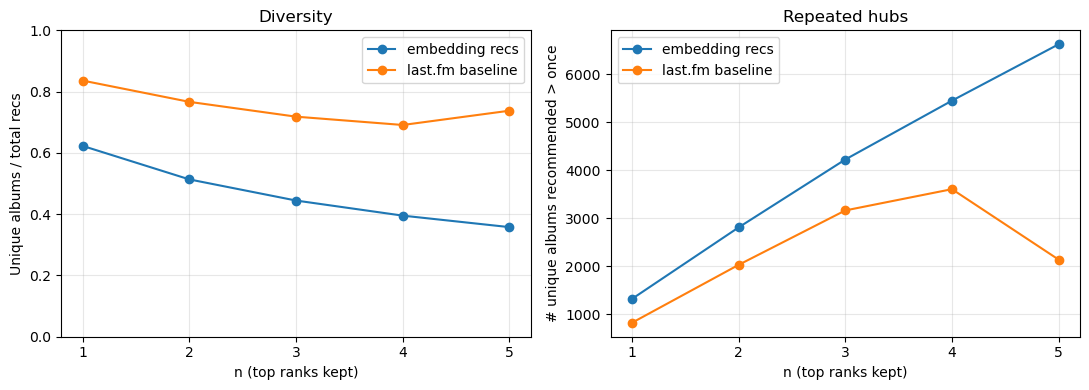

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, color in [
    ("embedding recs", "C0"),
    ("last.fm baseline", "C1"),
]:
    sub = repeated_sweep_albums[repeated_sweep_albums["recommender"] == label]
    axes[0].plot(sub["n"], sub["unique_share"], marker="o", label=label, color=color)
    axes[1].plot(sub["n"], sub["n_repeated"], marker="o", label=label, color=color)

axes[0].set(xlabel="n (top ranks kept)", ylabel="Unique albums / total recs", title="Diversity")
axes[0].set_xticks(range(1, TOP_N + 1))
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set(xlabel="n (top ranks kept)", ylabel="# unique albums recommended > once", title="Repeated hubs")
axes[1].set_xticks(range(1, TOP_N + 1))
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Artists

Same sweep on recommended **artist** names. Artist-level hub counts are often higher than album-level because one act can appear on many different albums.


In [ ]:
repeated_sweep_artists = repeated_sweep(recs_matched, baseline, "rec_artist", "repeated_artists")
repeated_sweep_artists

,metric,n,recommender,n_total,n_queries,n_unique,n_repeated,unique_share,repeated_share
0,repeated_artists,1,embedding recs,7278,7278,3632,1414,0.499038,0.389317
1,repeated_artists,1,last.fm baseline,7278,7278,4828,1265,0.663369,0.262013
2,repeated_artists,2,embedding recs,14556,7278,5271,2674,0.362119,0.507304
3,repeated_artists,2,last.fm baseline,14446,7223,7566,2732,0.523744,0.361089
4,repeated_artists,3,embedding recs,21834,7278,6427,3585,0.294357,0.557803
5,repeated_artists,3,last.fm baseline,20796,6932,9497,3866,0.456674,0.407076
6,repeated_artists,4,embedding recs,29112,7278,7325,4344,0.251614,0.593038
7,repeated_artists,4,last.fm baseline,22916,5729,9732,4204,0.424681,0.431977
8,repeated_artists,5,embedding recs,36390,7278,8091,4955,0.222341,0.612409
9,repeated_artists,5,last.fm baseline,14705,2941,6830,2889,0.464468,0.422987


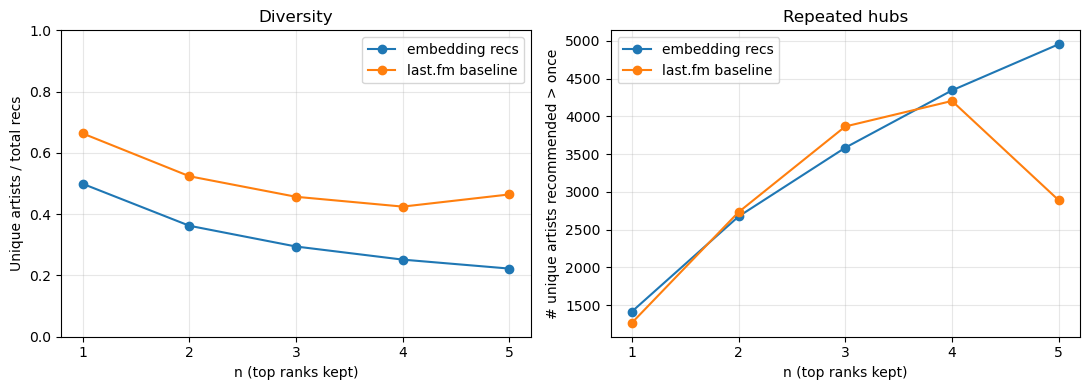

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, color in [
    ("embedding recs", "C0"),
    ("last.fm baseline", "C1"),
]:
    sub = repeated_sweep_artists[repeated_sweep_artists["recommender"] == label]
    axes[0].plot(sub["n"], sub["unique_share"], marker="o", label=label, color=color)
    axes[1].plot(sub["n"], sub["n_repeated"], marker="o", label=label, color=color)

axes[0].set(xlabel="n (top ranks kept)", ylabel="Unique artists / total recs", title="Diversity")
axes[0].set_xticks(range(1, TOP_N + 1))
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set(xlabel="n (top ranks kept)", ylabel="# unique artists recommended > once", title="Repeated hubs")
axes[1].set_xticks(range(1, TOP_N + 1))
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### Tags

Same sweep on **Last.fm top tags** attached to each recommended album (`rec_tags`). Each rec can contribute multiple tags, so counts are tag mentions rather than rec slots. At each `n`, only slots where **both** recommenders have tags are included (see Listener / tag overlap above).

In [ ]:
def repeated_tag_stats(df, n_comparable_slots):
    exploded = explode_rec_tags(df)
    n_queries = df.groupby(["query_artist", "query_album"], observed=True).ngroups
    if exploded.empty:
        return {
            "n_comparable_slots": n_comparable_slots,
            "n_total": 0,
            "n_queries": n_queries,
            "n_unique": 0,
            "n_repeated": 0,
            "unique_share": float("nan"),
            "repeated_share": float("nan"),
        }
    counts = exploded["rec_tag"].value_counts()
    n_total = len(exploded)
    n_unique = counts.size
    n_repeated = int((counts > 1).sum())
    return {
        "n_comparable_slots": n_comparable_slots,
        "n_total": n_total,
        "n_queries": n_queries,
        "n_unique": n_unique,
        "n_repeated": n_repeated,
        "unique_share": n_unique / n_total if n_total else float("nan"),
        "repeated_share": n_repeated / n_unique if n_unique else float("nan"),
    }


def repeated_tag_sweep(recs_df, baseline_df, top_n=TOP_N):
    rows = []
    for n in range(1, top_n + 1):
        recs_sub = _top_n_subset(recs_df, n)
        base_sub = _top_n_subset(baseline_df, n)
        slots = comparable_slots(recs_sub, base_sub, has_rec_tags)
        for label, source in [("embedding recs", recs_df), ("last.fm baseline", baseline_df)]:
            sub = filter_comparable_slots(_top_n_subset(source, n), slots)
            stats = repeated_tag_stats(sub, len(slots))
            rows.append({"metric": "repeated_tags", "n": n, "recommender": label, **stats})
    return pd.DataFrame(rows)


repeated_sweep_tags = repeated_tag_sweep(recs_matched, baseline)
repeated_sweep_tags

,metric,n,recommender,n_comparable_slots,n_total,n_queries,n_unique,n_repeated,unique_share,repeated_share
0,repeated_tags,1,embedding recs,1546,7693,1546,1159,588,0.150656,0.507334
1,repeated_tags,1,last.fm baseline,1546,7657,1546,1613,538,0.210657,0.333540
2,repeated_tags,2,embedding recs,3097,15429,2526,1683,948,0.109080,0.563280
3,repeated_tags,2,last.fm baseline,3097,15346,2526,2551,840,0.166232,0.329283
4,repeated_tags,3,embedding recs,4403,21942,3055,2000,1210,0.091149,0.605000
5,repeated_tags,3,last.fm baseline,4403,21814,3055,3231,1071,0.148116,0.331476
6,repeated_tags,4,embedding recs,4808,23956,2909,2049,1266,0.085532,0.617862
7,repeated_tags,4,last.fm baseline,4808,23870,2909,3372,1131,0.141265,0.335409
8,repeated_tags,5,embedding recs,3036,15127,1642,1689,928,0.111655,0.549438
9,repeated_tags,5,last.fm baseline,3036,15067,1642,2382,827,0.158094,0.347187


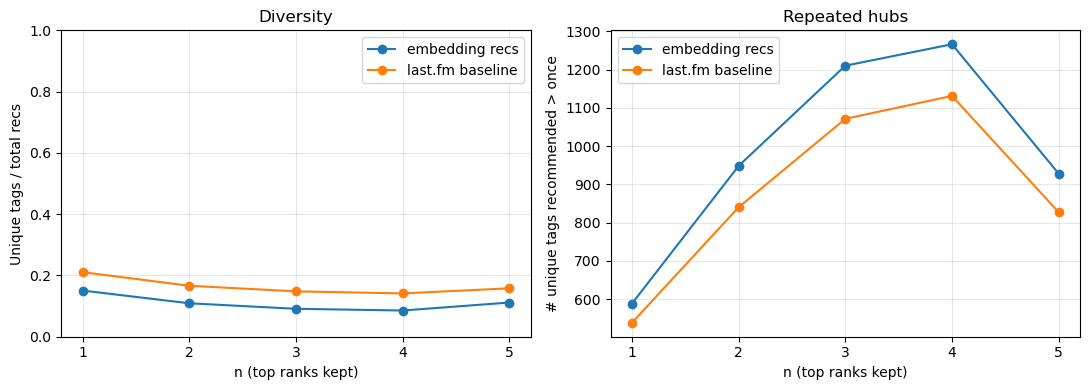

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, color in [
    ("embedding recs", "C0"),
    ("last.fm baseline", "C1"),
]:
    sub = repeated_sweep_tags[repeated_sweep_tags["recommender"] == label]
    axes[0].plot(sub["n"], sub["unique_share"], marker="o", label=label, color=color)
    axes[1].plot(sub["n"], sub["n_repeated"], marker="o", label=label, color=color)

axes[0].set(xlabel="n (top ranks kept)", ylabel="Unique tags / total recs", title="Diversity")
axes[0].set_xticks(range(1, TOP_N + 1))
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set(xlabel="n (top ranks kept)", ylabel="# unique tags recommended > once", title="Repeated hubs")
axes[1].set_xticks(range(1, TOP_N + 1))
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Variety

How spread out is each query's top-N list? **Repetition** measures whether different queries hit the same targets globally; **variety** measures diversity *within* a single query's list.

- **Variety ratio** = distinct rec targets ÷ list length (1.0 = every slot differs). For tags: distinct tags ÷ total tag mentions in the list.
- **All distinct** = share of queries whose full list has no repeats.
- **Single-target only** = share of queries where every rec is the same target (or one tag dominates the tag list).

**How to read:** compare emb vs base on full top-N lists. Album variety often nears the ceiling; artist and tag variety show larger gaps. Tag variety uses only **comparable slots** where both recommenders have `rec_tags` — check `n_comparable_slots` before comparing.

### Artists

Distinct recommended **artists** within each query's top-N list. Variety is often lower here because one act can fill multiple album slots.

In [ ]:
def list_variety_stats(df, kind):
    """Distinct rec targets within each query's recommendation list."""
    keys = ["query_artist", "query_album"]
    if kind == "album":
        target = rec_key(df)
    else:
        target = _norm(df["rec_artist"])

    stats = pd.DataFrame({"target": target, "n_recs": 1}).join(df[keys])
    stats = stats.groupby(keys, observed=True).agg(
        n_recs=("n_recs", "sum"),
        n_unique=("target", "nunique"),
    )
    stats["ratio"] = stats["n_unique"] / stats["n_recs"]
    return {
        "n_queries": len(stats),
        "mean_unique": stats["n_unique"].mean(),
        "mean_variety_ratio": stats["ratio"].mean(),
        "all_distinct_share": (stats["n_unique"] == stats["n_recs"]).mean(),
        "single_target_share": (stats["n_unique"] == 1).mean(),
    }


def _print_variety(row, label, top_n=TOP_N):
    print(f"[{row['recommender']}]")
    print(f"  Queries:              {row['n_queries']:,.0f}")
    print(f"  Mean unique {label}:  {row['mean_unique']:.2f} / {top_n}")
    print(f"  Mean variety ratio:   {row['mean_variety_ratio']:.1%}")
    print(f"  All distinct:         {row['all_distinct_share']:.1%}")
    print(f"  Single {label} only:  {row['single_target_share']:.1%}")
    print()


variety_sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
album_variety = pd.DataFrame(
    [metric_row("album_variety", label, **list_variety_stats(df, "album")) for label, df in variety_sources]
)

for _, row in album_variety.iterrows():
    _print_variety(row, "albums")

album_variety

### Artists

Distinct recommended **artists** within each query's top-N list. Variety is often lower here because one act can fill multiple album slots.

In [ ]:
artist_variety = pd.DataFrame(
    [metric_row("artist_variety", label, **list_variety_stats(df, "artist")) for label, df in variety_sources]
)

for _, row in artist_variety.iterrows():
    _print_variety(row, "artists")

artist_variety

NameError: name 'sources' is not defined

### Tags

Distinct **tags** within each query's top-N list (exploded from `rec_tags`). Variety is often lower than album-level because the same genre/style tag can appear on multiple recommended albums. Computed on comparable slots only (both recommenders have tags).

In [ ]:
def tag_variety_stats(df, n_comparable_slots):
    keys = ["query_artist", "query_album"]
    exploded = explode_rec_tags(df)
    n_queries = df.groupby(keys, observed=True).ngroups
    if exploded.empty:
        return {
            "n_comparable_slots": n_comparable_slots,
            "n_queries": n_queries,
            "queries_with_tags": 0,
            "queries_with_tags_share": 0.0,
            "mean_unique": float("nan"),
            "mean_variety_ratio": float("nan"),
            "all_distinct_share": float("nan"),
            "single_target_share": float("nan"),
        }

    stats = exploded.groupby(keys, observed=True).agg(
        n_mentions=("rec_tag", "size"),
        n_unique=("rec_tag", "nunique"),
    )
    stats["ratio"] = stats["n_unique"] / stats["n_mentions"]
    return {
        "n_comparable_slots": n_comparable_slots,
        "n_queries": n_queries,
        "queries_with_tags": len(stats),
        "queries_with_tags_share": len(stats) / n_queries if n_queries else float("nan"),
        "mean_unique": stats["n_unique"].mean(),
        "mean_variety_ratio": stats["ratio"].mean(),
        "all_distinct_share": (stats["n_unique"] == stats["n_mentions"]).mean(),
        "single_target_share": (stats["n_unique"] == 1).mean(),
    }


def _print_tag_variety(row):
    print(f"[{row['recommender']}]")
    print(f"  Comparable slots:     {row['n_comparable_slots']:,}")
    print(f"  Queries with tags:    {row['queries_with_tags']:,} / {row['n_queries']:,} ({row['queries_with_tags_share']:.1%})")
    print(f"  Mean unique tags:     {row['mean_unique']:.2f}")
    print(f"  Mean variety ratio:   {row['mean_variety_ratio']:.1%}")
    print(f"  All distinct:         {row['all_distinct_share']:.1%}")
    print(f"  Single tag only:      {row['single_target_share']:.1%}")
    print()


tag_sources = [
    ("embedding recs", recs_n_tags),
    ("last.fm baseline", baseline_n_tags),
]
tag_variety = pd.DataFrame(
    [
        metric_row("tag_variety", label, **tag_variety_stats(df, len(tag_slots_n)))
        for label, df in tag_sources
    ]
)

for _, row in tag_variety.iterrows():
    _print_tag_variety(row)

tag_variety

## Reciprocity

If artist A recommends artist B, does B recommend A back?

Each recommendation is a directed **edge**; a reciprocal pair `(A→B, B→A)` means mutual pointing. High reciprocity suggests **closed neighborhoods**. We measure at **artist** and **album** level.

**How to read:** **Reciprocal rate** = share of edges with a reverse partner. Artist level is more informative — mutual act links are more common than exact album reversals. Higher emb rate = embedding builds tighter mutual neighborhoods.

### Albums

Album-to-album edges use `query_artist::query_album → rec_artist::rec_album`. **Reciprocal rate** = share of edges whose reverse partner also appears.

In [ ]:
def reciprocity_stats(edges):
    reciprocal = sum(1 for a, b in edges if (b, a) in edges)
    n_edges = len(edges)
    return {
        "n_edges": n_edges,
        "n_reciprocal": reciprocal,
        "reciprocal_rate": reciprocal / n_edges if n_edges else float("nan"),
    }


def album_reciprocity_stats(df):
    edges = set(zip(
        _norm(df["query_artist"]) + "::" + _norm(df["query_album"]),
        _norm(df["rec_artist"]) + "::" + _norm(df["rec_album"]),
    ))
    return reciprocity_stats(edges)


def _print_reciprocity(row):
    print(f"[{row['recommender']}]")
    print(f"  Edges:       {row['n_edges']:,.0f}")
    print(f"  Reciprocal:  {row['n_reciprocal']:,.0f}")
    print(f"  Rate:        {row['reciprocal_rate']:.1%}")
    print()


sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
album_reciprocity = pd.DataFrame(
    [metric_row("album_reciprocity", label, **album_reciprocity_stats(df)) for label, df in sources]
)

for _, row in album_reciprocity.iterrows():
    _print_reciprocity(row)

album_reciprocity

### Artists

Artist-to-artist edges collapse to act names. Reciprocity is usually higher here than at album level.

In [ ]:
def artist_reciprocity_stats(df):
    edges = set(zip(_norm(df["query_artist"]), _norm(df["rec_artist"])))
    return reciprocity_stats(edges)


artist_reciprocity = pd.DataFrame(
    [metric_row("artist_reciprocity", label, **artist_reciprocity_stats(df)) for label, df in sources]
)

for _, row in artist_reciprocity.iterrows():
    _print_reciprocity(row)

artist_reciprocity

## Novelty

How uncommon are the recommended albums across query lists?

- **List reach** — avg # query lists each recommended album appears in (lower = more novel).
- **Singleton share** — share of rec slots where the album appears on only one list.
- **Self-information** — log₂(n_lists / reach) bits per rec slot (higher = album appears on fewer query lists).
- **Normalized novelty** — same self-information scaled to 0–1 (1 = unique to one list).
- **Effective catalog** — distinct albums implied if recs were spread uniformly.

**How to read:** lower reach and higher singleton share / self-information / effective catalog = more novel. Metrics should move together; higher reach with lower singleton share means the same albums recur across queries (see Repetition hubs).

In [ ]:
def _novelty_base(df):
    n_lists = df.groupby(["query_artist", "query_album"], observed=True).ngroups
    key = rec_key(df)
    reach = key.map(key.value_counts())
    return n_lists, reach


def list_reach_stats(df):
    n_lists, reach = _novelty_base(df)
    return {"n_lists": n_lists, "mean_reach": reach.mean(), "median_reach": reach.median()}


def singleton_share_stats(df):
    _, reach = _novelty_base(df)
    return {"singleton_share": (reach == 1).mean()}


def _self_information(df):
    n_lists, reach = _novelty_base(df)
    return np.log2(n_lists / reach)


def self_information_stats(df):
    info = _self_information(df)
    return {"mean_self_information": info.mean(), "median_self_information": info.median()}


def normalized_novelty_stats(df):
    n_lists, reach = _novelty_base(df)
    info = np.log2(n_lists / reach)
    log_n = np.log2(n_lists)
    norm = info / log_n if log_n else reach * 0
    return {"mean_novelty": norm.mean(), "median_novelty": norm.median()}


def effective_catalog_stats(df):
    key = rec_key(df)
    counts = key.value_counts()
    p = counts / counts.sum()
    return {"effective_catalog": 2 ** (-(p * np.log2(p)).sum())}


sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
rows = []
for label, df in sources:
    row = {"recommender": label}
    row.update(list_reach_stats(df))
    row.update(singleton_share_stats(df))
    row.update(self_information_stats(df))
    row.update(normalized_novelty_stats(df))
    row.update(effective_catalog_stats(df))
    rows.append(row)

novelty = pd.DataFrame(rows)

for _, row in novelty.iterrows():
    print(f"[{row['recommender']}]")
    print(f"  List reach (mean):   {row['mean_reach']:.2f}")
    print(f"  Singleton share:     {row['singleton_share']:.1%}")
    print(f"  Self-information:    {row['mean_self_information']:.2f} bits")
    print(f"  Normalized novelty:  {row['mean_novelty']:.1%}")
    print(f"  Effective catalog:   {row['effective_catalog']:,.0f}")
    print()

novelty

## Catalog overlap & concentration

How do recommendations relate to the review catalog (`albums.csv`)? Embedding is index-constrained; Last.fm is open-world.

- **In-corpus rec share** — share of rec slots landing in `albums.csv`.
- **Distinct in-corpus albums** — review-catalog albums recommended at least once.
- **Review-catalog share** — index utilization (emb) vs in-corpus overlap (Last.fm).
- **Top-1% concentration** — share of slots going to the most-recommended albums.

**How to read:** in-corpus share and concentration compare directly. Review-catalog share is asymmetric — index coverage for embedding, overlap with your corpus for Last.fm. Low Last.fm in-corpus share reflects its open catalog, not "using less" of albums.csv.

In [ ]:
def catalog_overlap_stats(df):
    key = rec_key(df)
    in_catalog = key.isin(catalog_reviews.index)
    in_corpus = key[in_catalog]
    counts = key.value_counts()
    top1pct = max(1, int(len(counts) * 0.01))
    n_catalog = len(catalog)
    n_in_corpus = in_corpus.nunique()
    return {
        "in_corpus_rec_share": in_catalog.mean(),
        "n_distinct_recs": key.nunique(),
        "n_in_corpus_albums": n_in_corpus,
        "n_catalog_albums": n_catalog,
        "review_catalog_share": n_in_corpus / n_catalog if n_catalog else float("nan"),
        "top1pct_slot_share": counts.head(top1pct).sum() / counts.sum() if len(counts) else float("nan"),
    }


sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
catalog_overlap = pd.DataFrame(
    [metric_row("catalog_overlap", label, **catalog_overlap_stats(df)) for label, df in sources]
)

for _, row in catalog_overlap.iterrows():
    label = "Index coverage" if row["recommender"] == "embedding recs" else "In-corpus overlap"
    print(f"[{row['recommender']}]")
    print(f"  In-corpus recs:       {row['in_corpus_rec_share']:.1%}")
    print(f"  Distinct rec albums:  {row['n_distinct_recs']:,.0f}  ({row['n_in_corpus_albums']:,.0f} in corpus)")
    print(f"  {label}:            {row['n_in_corpus_albums']:,.0f} / {row['n_catalog_albums']:,.0f} ({row['review_catalog_share']:.1%})")
    print(f"  Top 1% concentration: {row['top1pct_slot_share']:.1%}")
    print()

catalog_overlap

## Popularity bias

Do recommended albums skew more popular than the catalog — or than the query albums that produced them?

- **Review count** — mean `review_count` of in-catalog recs vs catalog mean (both recommenders; `albums.csv` only). Ratio > 1 = popularity bias.
- **Last.fm listeners** — median listeners of rec vs query album. Computed on **comparable slots** where both recommenders have `rec_listeners` and `query_listeners`.

**How to read:** review-count stats only cover in-corpus recs — check catalog-overlap coverage first. Listener bias uses the shared comparable overlap only — check `n_comparable_slots` (much smaller than baseline-only coverage).

### Review count

Popularity proxy from the review catalog. **Ratio > 1** means in-catalog recommendations lean toward albums with more reviews than the catalog average.

In [ ]:
def review_count_bias_stats(df):
    rec_reviews = rec_key(df).map(catalog_reviews)
    in_corpus = rec_reviews.notna()
    rec_reviews = rec_reviews[in_corpus]
    catalog_mean = catalog_reviews.mean()
    return {
        "in_corpus_rec_share": in_corpus.mean(),
        "mean_reviews_recs": rec_reviews.mean(),
        "mean_reviews_catalog": catalog_mean,
        "mean_reviews_ratio": rec_reviews.mean() / catalog_mean,
        "recs_3plus_share": (rec_reviews >= 3).mean(),
        "catalog_3plus_share": (catalog_reviews >= 3).mean(),
    }


sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
review_count_bias = pd.DataFrame(
    [metric_row("review_count_bias", label, **review_count_bias_stats(df)) for label, df in sources]
)

for _, row in review_count_bias.iterrows():
    print(f"[{row['recommender']}]")
    print(f"  In-corpus recs:     {row['in_corpus_rec_share']:.1%}")
    print(f"  Mean reviews ratio: {row['mean_reviews_ratio']:.2f}x  (catalog mean: {row['mean_reviews_catalog']:.2f})")
    print(f"  3+ reviews share:   {row['recs_3plus_share']:.1%}  (catalog: {row['catalog_3plus_share']:.1%})")
    print()

review_count_bias

### Last.fm listeners

Are recommendations more listened-to than the query albums that produced them? **Rec/query ratio > 1** means the recommender tends to surface more popular albums than the seed. **Catalog mean** is the mean `lastfm_listeners` across `albums.csv` (albums with listener data only) — a baseline for how popular the review corpus is on Last.fm.

In [ ]:
catalog_mean_listeners = catalog_listeners.dropna().mean()
catalog_listener_coverage = catalog_listeners.notna().mean()


def listener_popularity_stats(df, n_comparable_slots):
    sub = df.dropna(subset=["rec_listeners", "query_listeners"])
    if sub.empty:
        return {
            "n_comparable_slots": n_comparable_slots,
            "n_rows_with_data": 0,
            "mean_listeners_catalog": catalog_mean_listeners,
            "catalog_listener_coverage": catalog_listener_coverage,
            "median_rec_listeners": float("nan"),
            "median_query_listeners": float("nan"),
            "median_rec_query_ratio": float("nan"),
            "median_rec_catalog_ratio": float("nan"),
            "rec_more_popular_share": float("nan"),
        }
    ratio = (sub["rec_listeners"] + 1) / (sub["query_listeners"] + 1)
    median_rec = sub["rec_listeners"].median()
    return {
        "n_comparable_slots": n_comparable_slots,
        "n_rows_with_data": len(sub),
        "mean_listeners_catalog": catalog_mean_listeners,
        "catalog_listener_coverage": catalog_listener_coverage,
        "median_rec_listeners": median_rec,
        "median_query_listeners": sub["query_listeners"].median(),
        "median_rec_query_ratio": ratio.median(),
        "median_rec_catalog_ratio": median_rec / catalog_mean_listeners if catalog_mean_listeners else float("nan"),
        "rec_more_popular_share": (ratio > 1).mean(),
    }


listener_sources = [
    ("embedding recs", recs_n_listeners),
    ("last.fm baseline", baseline_n_listeners),
]
listener_popularity = pd.DataFrame(
    [
        metric_row("listener_popularity", label, **listener_popularity_stats(df, len(listener_slots_n)))
        for label, df in listener_sources
    ]
)

print(
    f"Catalog mean listeners: {catalog_mean_listeners:,.0f} "
    f"({catalog_listener_coverage:.1%} of albums.csv have Last.fm data)"
)
print()

for _, row in listener_popularity.iterrows():
    if row["n_rows_with_data"] == 0:
        print(f"[{row['recommender']}]  no comparable listener slots")
        print()
        continue
    print(f"[{row['recommender']}]")
    print(f"  Comparable slots:      {row['n_comparable_slots']:,}")
    print(
        f"  Median rec listeners:  {row['median_rec_listeners']:,.0f} "
        f"(catalog mean: {row['mean_listeners_catalog']:,.0f})"
    )
    print(f"  Median query listeners:{row['median_query_listeners']:,.0f}")
    print(f"  Rec/query ratio:       {row['median_rec_query_ratio']:.2f}x")
    print(f"  Rec/catalog ratio:     {row['median_rec_catalog_ratio']:.2f}x")
    print(f"  Rec more popular:      {row['rec_more_popular_share']:.1%}")
    print()

listener_popularity

## Unexpectedness

How much do the two recommenders disagree on shared queries? We sweep list depth `n = 1 … TOP_N`.

### Albums

- **Full-list Jaccard** — overlap of the top-`n` rec lists (0 = none, 1 = identical). Last.fm includes many out-of-corpus albums, so this mixes catalog mismatch with disagreement.
- **In-corpus Jaccard** — same measure on `albums.csv` recs only, for queries where **both** sides have ≥ `n` in-corpus albums in their top-`n` lists.

### Tags

- **Tag Jaccard** — overlap of the union of `rec_tags` across each query's top-`n` list.
- **Comparable tag Jaccard** — same measure using only ranks where **both** recommenders have non-empty `rec_tags`.

**How to read:** focus on **n = 1** and **n = TOP_N**. Low album Jaccard is expected when Last.fm sits outside your index. Tag Jaccard needs Last.fm tag metadata — check comparable query counts before comparing.

### Albums

In [24]:
def rec_lists(df):
    frame = pd.DataFrame({
        "query": query_key(df),
        "rec": rec_key(df),
    })
    return frame.groupby("query")["rec"].agg(set)


def _jaccard(lists_a, lists_b, queries):
    values = []
    for q in queries:
        union = lists_a[q] | lists_b[q]
        values.append(len(lists_a[q] & lists_b[q]) / len(union) if union else float("nan"))
    return pd.Series(values, index=queries)


def unexpectedness_stats(df_a, df_b, n, min_in_corpus=None):
    if min_in_corpus is None:
        min_in_corpus = n
    sub_a = _top_n_subset(df_a, n)
    sub_b = _top_n_subset(df_b, n)
    lists_a, lists_b = rec_lists(sub_a), rec_lists(sub_b)
    shared = lists_a.index.intersection(lists_b.index)
    empty = {"n": n, "n_shared_queries": 0, "min_in_corpus": min_in_corpus}
    nan_metrics = {
        "mean_jaccard": float("nan"),
        "zero_overlap_share": float("nan"),
        "any_overlap_share": float("nan"),
        "n_comparable_queries": 0,
        "comparable_query_share": float("nan"),
        "mean_jaccard_in_corpus": float("nan"),
        "zero_overlap_in_corpus_share": float("nan"),
        "any_overlap_in_corpus_share": float("nan"),
    }
    if shared.empty:
        return {**empty, **nan_metrics}

    j_full = _jaccard(lists_a, lists_b, shared)
    catalog_keys = set(catalog_reviews.index)
    in_a = lists_a.map(lambda s: s & catalog_keys)
    in_b = lists_b.map(lambda s: s & catalog_keys)
    comparable = [q for q in shared if len(in_a[q]) >= min_in_corpus and len(in_b[q]) >= min_in_corpus]
    out = {
        "n": n,
        "n_shared_queries": len(shared),
        "min_in_corpus": min_in_corpus,
        "mean_jaccard": j_full.mean(),
        "zero_overlap_share": (j_full == 0).mean(),
        "any_overlap_share": (j_full > 0).mean(),
        "n_comparable_queries": len(comparable),
        "comparable_query_share": len(comparable) / len(shared),
    }
    if comparable:
        j_inc = _jaccard(in_a, in_b, comparable)
        out.update(
            {
                "mean_jaccard_in_corpus": j_inc.mean(),
                "zero_overlap_in_corpus_share": (j_inc == 0).mean(),
                "any_overlap_in_corpus_share": (j_inc > 0).mean(),
            }
        )
    else:
        out.update(
            {
                "mean_jaccard_in_corpus": float("nan"),
                "zero_overlap_in_corpus_share": float("nan"),
                "any_overlap_in_corpus_share": float("nan"),
            }
        )
    return out


def unexpectedness_sweep(df_a, df_b, top_n=TOP_N):
    return pd.DataFrame(
        [metric_row("unexpectedness", **unexpectedness_stats(df_a, df_b, n)) for n in range(1, top_n + 1)]
    )


unexpectedness = unexpectedness_sweep(recs_matched, baseline)

if unexpectedness["n_shared_queries"].eq(0).all():
    print("No shared query albums")
else:
    for _, row in unexpectedness.iterrows():
        n = int(row["n"])
        print(f"n = {n}")
        print(f"  Shared queries: {row['n_shared_queries']:,.0f}")
        print(f"  Full-list mean Jaccard: {row['mean_jaccard']:.1%}")
        print(f"  Any overlap:            {row['any_overlap_share']:.1%}")
        if row["n_comparable_queries"]:
            print(
                f"  In-corpus mean Jaccard: {row['mean_jaccard_in_corpus']:.1%} "
                f"({row['n_comparable_queries']:,.0f} / {row['n_shared_queries']:,.0f} queries)"
            )
        else:
            print("  In-corpus mean Jaccard: n/a (no comparable queries)")
        print()

unexpectedness

n = 1
  Shared queries: 7,278
  Full-list mean Jaccard: 0.8%
  Any overlap:            0.8%
  In-corpus mean Jaccard: 2.8% (2,089 / 7,278 queries)

n = 2
  Shared queries: 7,223
  Full-list mean Jaccard: 0.6%
  Any overlap:            1.9%
  In-corpus mean Jaccard: 2.0% (998 / 7,223 queries)

n = 3
  Shared queries: 6,932
  Full-list mean Jaccard: 0.6%
  Any overlap:            2.8%
  In-corpus mean Jaccard: 1.4% (566 / 6,932 queries)

n = 4
  Shared queries: 5,729
  Full-list mean Jaccard: 0.6%
  Any overlap:            3.6%
  In-corpus mean Jaccard: 1.3% (316 / 5,729 queries)

n = 5
  Shared queries: 2,941
  Full-list mean Jaccard: 0.4%
  Any overlap:            3.6%
  In-corpus mean Jaccard: 1.1% (101 / 2,941 queries)



,metric,n,n_shared_queries,min_in_corpus,mean_jaccard,zero_overlap_share,any_overlap_share,n_comparable_queries,comparable_query_share,mean_jaccard_in_corpus,zero_overlap_in_corpus_share,any_overlap_in_corpus_share
0,unexpectedness,1,7278,1,0.007969,0.992031,0.007969,2089,0.287029,0.027764,0.972236,0.027764
1,unexpectedness,2,7223,2,0.006461,0.981448,0.018552,998,0.138170,0.020040,0.945892,0.054108
2,unexpectedness,3,6932,3,0.006239,0.971870,0.028130,566,0.081650,0.014311,0.936396,0.063604
3,unexpectedness,4,5729,4,0.005730,0.963693,0.036307,316,0.055158,0.013412,0.914557,0.085443
4,unexpectedness,5,2941,5,0.004349,0.964298,0.035702,101,0.034342,0.011276,0.910891,0.089109


### Tags

In [25]:
def tag_lists(df):
    exploded = explode_rec_tags(df)
    if exploded.empty:
        return pd.Series(dtype=object)
    frame = exploded.assign(query=query_key(exploded))
    return frame.groupby("query")["rec_tag"].agg(set)


def _comparable_tag_queries(df_a, df_b, n):
    sub_a = _top_n_subset(df_a, n)
    sub_b = _top_n_subset(df_b, n)
    slots = comparable_slots(sub_a, sub_b, has_rec_tags)
    comp_a = filter_comparable_slots(sub_a, slots)
    comp_b = filter_comparable_slots(sub_b, slots)
    counts_a = comp_a.assign(query=query_key(comp_a)).groupby("query", observed=True).size()
    counts_b = comp_b.assign(query=query_key(comp_b)).groupby("query", observed=True).size()
    shared = counts_a.index.intersection(counts_b.index)
    return [q for q in shared if counts_a[q] >= n and counts_b[q] >= n]


def tag_unexpectedness_stats(df_a, df_b, n):
    sub_a = _top_n_subset(df_a, n)
    sub_b = _top_n_subset(df_b, n)
    slots = comparable_slots(sub_a, sub_b, has_rec_tags)
    comp_a = filter_comparable_slots(sub_a, slots)
    comp_b = filter_comparable_slots(sub_b, slots)

    lists_a, lists_b = tag_lists(sub_a), tag_lists(sub_b)
    shared = lists_a.index.intersection(lists_b.index)
    nan_metrics = {
        "mean_jaccard": float("nan"),
        "zero_overlap_share": float("nan"),
        "any_overlap_share": float("nan"),
        "n_comparable_queries": 0,
        "comparable_query_share": float("nan"),
        "mean_jaccard_comparable": float("nan"),
        "zero_overlap_comparable_share": float("nan"),
        "any_overlap_comparable_share": float("nan"),
    }
    empty = {"n": n, "n_shared_queries": 0}
    if shared.empty:
        return {**empty, **nan_metrics}

    j_full = _jaccard(lists_a, lists_b, shared).dropna()
    comparable = _comparable_tag_queries(df_a, df_b, n)
    comp_lists_a, comp_lists_b = tag_lists(comp_a), tag_lists(comp_b)

    out = {
        "n": n,
        "n_shared_queries": len(shared),
        "mean_jaccard": j_full.mean() if len(j_full) else float("nan"),
        "zero_overlap_share": (j_full == 0).mean() if len(j_full) else float("nan"),
        "any_overlap_share": (j_full > 0).mean() if len(j_full) else float("nan"),
        "n_comparable_queries": len(comparable),
        "comparable_query_share": len(comparable) / len(shared) if len(shared) else float("nan"),
    }
    if comparable:
        j_comp = _jaccard(comp_lists_a, comp_lists_b, comparable).dropna()
        out.update(
            {
                "mean_jaccard_comparable": j_comp.mean() if len(j_comp) else float("nan"),
                "zero_overlap_comparable_share": (j_comp == 0).mean() if len(j_comp) else float("nan"),
                "any_overlap_comparable_share": (j_comp > 0).mean() if len(j_comp) else float("nan"),
            }
        )
    else:
        out.update(
            {
                "mean_jaccard_comparable": float("nan"),
                "zero_overlap_comparable_share": float("nan"),
                "any_overlap_comparable_share": float("nan"),
            }
        )
    return out


def tag_unexpectedness_sweep(df_a, df_b, top_n=TOP_N):
    return pd.DataFrame(
        [metric_row("tag_unexpectedness", **tag_unexpectedness_stats(df_a, df_b, n)) for n in range(1, top_n + 1)]
    )


tag_unexpectedness = tag_unexpectedness_sweep(recs_matched, baseline)

if tag_unexpectedness["n_shared_queries"].eq(0).all():
    print("No shared query albums")
else:
    for _, row in tag_unexpectedness.iterrows():
        n = int(row["n"])
        print(f"n = {n}")
        print(f"  Shared queries: {row['n_shared_queries']:,.0f}")
        print(f"  Tag mean Jaccard: {row['mean_jaccard']:.1%}")
        print(f"  Any tag overlap:  {row['any_overlap_share']:.1%}")
        if row["n_comparable_queries"]:
            print(
                f"  Comparable tag Jaccard: {row['mean_jaccard_comparable']:.1%} "
                f"({row['n_comparable_queries']:,.0f} / {row['n_shared_queries']:,.0f} queries)"
            )
        else:
            print("  Comparable tag Jaccard: n/a (no comparable queries)")
        print()

tag_unexpectedness

n = 1
  Shared queries: 1,546
  Tag mean Jaccard: 13.9%
  Any tag overlap:  55.6%
  Comparable tag Jaccard: 13.9% (1,546 / 1,546 queries)

n = 2
  Shared queries: 2,648
  Tag mean Jaccard: 13.3%
  Any tag overlap:  67.9%
  Comparable tag Jaccard: 16.2% (571 / 2,648 queries)

n = 3
  Shared queries: 3,212
  Tag mean Jaccard: 12.8%
  Any tag overlap:  74.0%
  Comparable tag Jaccard: 15.8% (196 / 3,212 queries)

n = 4
  Shared queries: 3,046
  Tag mean Jaccard: 12.6%
  Any tag overlap:  79.3%
  Comparable tag Jaccard: 16.1% (51 / 3,046 queries)

n = 5
  Shared queries: 1,710
  Tag mean Jaccard: 12.3%
  Any tag overlap:  83.0%
  Comparable tag Jaccard: 15.5% (4 / 1,710 queries)



,metric,n,n_shared_queries,mean_jaccard,zero_overlap_share,any_overlap_share,n_comparable_queries,comparable_query_share,mean_jaccard_comparable,zero_overlap_comparable_share,any_overlap_comparable_share
0,tag_unexpectedness,1,1546,0.139234,0.443726,0.556274,1546,1.000000,0.139234,0.443726,0.556274
1,tag_unexpectedness,2,2648,0.133364,0.321375,0.678625,571,0.215634,0.161694,0.173380,0.826620
2,tag_unexpectedness,3,3212,0.128196,0.259963,0.740037,196,0.061021,0.158233,0.066327,0.933673
3,tag_unexpectedness,4,3046,0.125599,0.207485,0.792515,51,0.016743,0.160905,0.058824,0.941176
4,tag_unexpectedness,5,1710,0.122663,0.169591,0.830409,4,0.002339,0.154731,0.000000,1.000000


## Serendipity

How often are recs "relevant but not obvious"?

This is a **rough proxy**, not full serendipity (which also needs relevance and user surprise). Each **rec slot** is scored independently.

- **Same-artist share** — recommended artist equals the query artist. Last.fm tries to exclude these; embedding is not filtered the same way.
- **Serendipitous (review count)** — different artist, in `albums.csv`, and `review_count` ≤ catalog median (currently 1).
- **Serendipitous (listeners)** — different artist and `rec_listeners` ≤ catalog median Last.fm listeners.

Review-count serendipity reports an **all-slots** rate and a **fair-comparison** rate (in-corpus only). Listener serendipity uses **comparable slots** where both recommenders have listener data.

**How to read:** compare rates across recommenders on the same denominator. Review-count all-slots rates are dominated by in-corpus coverage (~96% emb vs ~31% Last.fm). Listener rates use comparable overlap only — check `n_comparable_slots`.

### Review count

"Obscure" = at or below the catalog median `review_count` (currently 1). **Serendipitous (in-corpus)** is the fair comparison rate when in-corpus coverage differs.

In [ ]:
def serendipity_lite_stats(df):
    same_artist = _norm(df["rec_artist"]) == _norm(df["query_artist"])
    rec_reviews = rec_key(df).map(catalog_reviews)
    median_reviews = catalog_reviews.median()
    in_corpus = rec_reviews.notna()
    obscure = rec_reviews <= median_reviews
    serendipitous = ~same_artist & obscure
    return {
        "catalog_median_review_count": median_reviews,
        "in_corpus_share": in_corpus.mean(),
        "same_artist_share": same_artist.mean(),
        "serendipitous_share": serendipitous.mean(),
        "serendipitous_in_corpus_share": serendipitous[in_corpus].mean() if in_corpus.any() else float("nan"),
    }


sources = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]
serendipity_lite = pd.DataFrame(
    [metric_row("serendipity_lite", label, **serendipity_lite_stats(df)) for label, df in sources]
)

for _, row in serendipity_lite.iterrows():
    print(f"[{row['recommender']}]")
    print(f"  In-corpus recs:              {row['in_corpus_share']:.1%}")
    print(f"  Same-artist recs:            {row['same_artist_share']:.1%}")
    print(f"  Serendipitous (all slots):   {row['serendipitous_share']:.1%}")
    print(f"  Serendipitous (in-corpus):   {row['serendipitous_in_corpus_share']:.1%}")
    print(f"  (median review_count = {row['catalog_median_review_count']:.0f})")
    print()

serendipity_lite

### Last.fm listeners

"Obscure" = `rec_listeners` at or below the catalog median Last.fm listeners. **Serendipitous (with listener data)** is the fair comparison rate while embedding listener coverage is still partial.

In [ ]:
def serendipity_listener_stats(df, n_comparable_slots):
    same_artist = _norm(df["rec_artist"]) == _norm(df["query_artist"])
    median_listeners = catalog_listeners.median()
    obscure = df["rec_listeners"] <= median_listeners
    serendipitous = ~same_artist & obscure
    return {
        "catalog_median_listeners": median_listeners,
        "n_comparable_slots": n_comparable_slots,
        "same_artist_share": same_artist.mean(),
        "serendipitous_listener_share": serendipitous.mean(),
    }


serendipity_listener_sources = [
    ("embedding recs", recs_n_listeners),
    ("last.fm baseline", baseline_n_listeners),
]
serendipity_listener = pd.DataFrame(
    [
        metric_row("serendipity_listener", label, **serendipity_listener_stats(df, len(listener_slots_n)))
        for label, df in serendipity_listener_sources
    ]
)

for _, row in serendipity_listener.iterrows():
    print(f"[{row['recommender']}]")
    print(f"  Comparable slots:          {row['n_comparable_slots']:,}")
    print(f"  Same-artist recs:            {row['same_artist_share']:.1%}")
    print(f"  Serendipitous (listeners):   {row['serendipitous_listener_share']:.1%}")
    print(f"  (median listeners = {row['catalog_median_listeners']:,.0f})")
    print()

serendipity_listener